In [ ]:
import scanpy as sc
import pickle as pickle
import pandas as pd
import numpy as np
from os.path import exists
import matplotlib.pyplot as plt
import random
import os
import re
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Rectangle

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
def compute_transition_scores(data, clusters, chosen_transitions, percentile = 0.9):
    '''Calculates a score indicating the probability that two clusters are a cell state transition.
    The score says what percentage of posterior samples in the second cluster are larger than the 
    95th percentile of the first cluster. Scores below 0.5 indicate uncertain transitions.
    
    Parameters
    ----------
    mod
        Trained model with posterior samples.
    cluster
        Cluster identity of cells in the data.
    chosen_transitions
        List with pairs of clusters to calculate transition scores for.
    percentile
        Percentile threshold to use in score calculation. Default is 0.95.

    Returns
    -------
    Dataframe with scores for each transition'''
    
    T_c = data['T_c']
    tab = pd.DataFrame(columns = ('Transition', 'Score'), index = list(range(len(chosen_transitions))))
    categories = clusters
    for i in range(len(chosen_transitions)):
        tab.loc[i, 'Transition'] = chosen_transitions[i]
        if np.sum(categories == chosen_transitions[i][0]) > 0:
            tab.loc[i, 'Score'] = np.sum(np.quantile(T_c[categories == chosen_transitions[i][0]], percentile) < T_c[categories == chosen_transitions[i][1]])/np.sum(categories == chosen_transitions[i][1])
    return tab

In [ ]:
chosen_transitions = [('OPC-NPC-like', 'Neuron-like'),
                      ('Neuron-like', 'AC-gliosis-hypoxia'), 
                      ('OPC-NPC-like', 'AC-gliosis-hypoxia')]

In [ ]:
data_dir = '../data/GBM/'
clone_dir = '../data/GBM/clones/'
save_dir = '../data/cell2fate/'

outdir = '../data/trajectories/plots/'
patients = np.array(('at12', 'at14', 'at4', 'at6', 'at9', 'at11', 'at13', 
                     'at15', 'at5', 'at7', 'at10', 'at3'))
good_clones = ['at4_0',
 'at10_1',
 'at15_3',
 'at4_2',
 'at6_0',
 'at4_1',
 'at10_2',
 'at9_2',
 'at15_4',
 'at15_0',
 'at15_6',
 'at15_2',
 'at10_0',
 'at5_9',
 'at5_4',
 'at5_2',
 'at9_4',
 'at9_0',
 'at3_3',
 'at13_0',
 'at6_4',
 'at7_0',
 'at6_5']

In [ ]:
label_map = pd.read_csv('../../../data/GBM_LEAP_annotations/annotation_hierarchy.tsv', 
                        sep = '\t').fillna('')

# Compute transition scores (class-level)

In [ ]:
all_scores = pd.DataFrame(columns = chosen_transitions + ['Average'])

path = save_dir
time_tab_list = []
seed = 0
for i in range(len(patients)):
    patient = patients[i]
    print(patient)
    clones = pd.read_csv(clone_dir + patient + '_2.h5ad')
    unique_clones = np.unique(clones['predicted'])
    for j in range(len(unique_clones)):
        print(j)
        filename = save_dir + patient + 'clone' + str(unique_clones[j]) + '_2_new2.pickle'
        with open(filename, 'rb') as handle:
            data = pickle.load(handle)

        # Extract the granular cell type column as a Pandas Series
        granular_series = data['TME_GBM_granular']
        # Ensure the label_map DataFrame is indexed by the granular cell type column
        label_map_indexed = label_map.set_index('TME_GBM_granular')
        # Map granular cell types to broad cell types using the label_map
        broad_types = granular_series.map(label_map_indexed['cell_class'])
        # Add the broad cell type identities as a new column in the dictionary
        data['TME_GBM_broad'] = broad_types
        scores = compute_transition_scores(data, data['TME_GBM_broad'], chosen_transitions, percentile = 0.9)
        all_scores.loc[patient + '_' + str(j),:] = np.array(list(scores['Score']) + [np.mean(scores['Score'])])

In [ ]:
all_scores.to_csv(outdir+'transition_scores.csv')

# Load transition scores (main QC plots)

In [ ]:
all_scores = pd.read_csv(outdir+'transition_scores.csv', index_col=0)
all_scores = all_scores.drop('max_time', axis=1)

In [ ]:
max_time = []
for clone in all_scores['index']:
    file = '../data/cell2fate/LatestRun{}.csv'.format(clone)
    if exists(file):
        df = pd.read_csv(file)
        max_time.append(pd.DataFrame({'index':clone, 
                                      'counts':len(df),
                                      'max_time':df['Time (hours)'].max()}, index=[0]))
max_time = pd.concat(max_time, ignore_index=True)

In [ ]:
all_scores = all_scores.sort_values('Average', ascending=False)
all_scores = all_scores.reset_index().merge(max_time, on = 'index')

In [ ]:
all_scores['pass_counts'] = all_scores['counts']>=2000
all_scores['good_clones'] = all_scores['index'].isin(good_clones)

In [ ]:
#all_scores['pass'] = all_scores['max_time']>25

pass_dict = {True:'#1f77b4',
        False:'#7f7f7f'}
pass_counts_dict = {True:'#1f77b4',
        False:'lightsteelblue'}

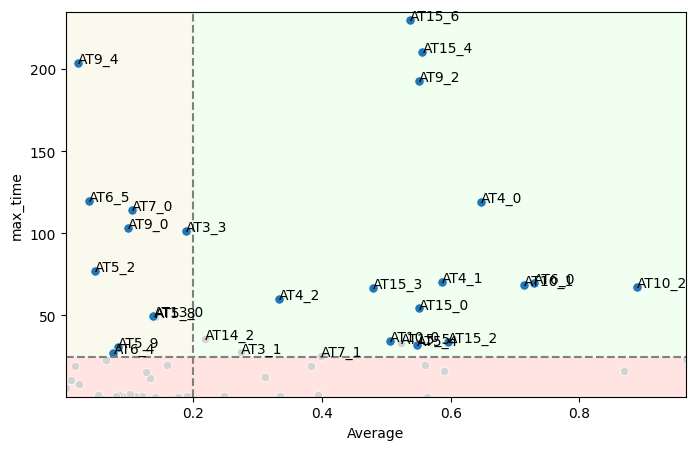

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

#ax = sns.scatterplot(data=all_scores, x = 'Average',  y = 'max_time', hue = 'pass',
#                    palette = pass_dict)

# failed points
sns.scatterplot(
    data=all_scores[~all_scores["good_clones"]],
    x="Average",
    y="max_time",
    color="lightgrey",
    ax=ax
)

# passing points with colormap
sns.scatterplot(
    data=all_scores[all_scores["good_clones"]],
    x="Average",
    y="max_time",
    color = '#1f77b4',
    #hue = 'pass_counts',
    #palette=pass_counts_dict,
    ax=ax,
    s = 45
)

# threshold condition
mask = all_scores['pass']
for _, row in all_scores[mask].iterrows():
    ax.text(x = row["Average"], y = row["max_time"], s = row["index"].upper())


plt.axvline(0.2, linestyle = '--', color = 'grey')
plt.axhline(25, linestyle = '--', color = 'grey')

xmin = all_scores['Average'].min()
xmax = all_scores['Average'].max()
ymin = all_scores['max_time'].min()
ymax = all_scores['max_time'].max()+5


rect1 = Rectangle(
    (xmin, 25),
    0.2 - xmin,
    ymax - 25,
    color="beige",
    alpha=0.5,
    zorder=-1
)
rect2 = Rectangle(
    (0.2, 25),
    xmax - 0.2,
    ymax - 25,
    color="honeydew",
    alpha=1,
    zorder=-1
)

ax.add_patch(rect1)
ax.add_patch(rect2)

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.axhspan(0, 25, color = 'mistyrose', alpha = 1, zorder=-1)

plt.savefig(outdir+'transition_scores.pdf')

In [ ]:
all_scores[all_scores["good_clones"]].drop('level_0',axis=1)\
    .to_csv('../../../data/EDFig6/EDFig6b.csv')

In [ ]:
all_scores['donor'] = [re.sub('_.*$', '', i).upper() for i in all_scores['index']]
all_scores['module'] = [re.sub('^.*_', '', i) for i in all_scores['index']]
all_scores['counts'] = all_scores['counts'].astype(int)

count_df = all_scores.pivot(index='donor', columns='module', values='counts').round(0)
count_df = count_df.sort_index(key=lambda x: x.str.extract(r'(\d+)').astype(int)[0])

pass_df = all_scores.pivot(index='donor', columns='module', values='good_clones')
pass_df = pass_df.sort_index(key=lambda x: x.str.extract(r'(\d+)').astype(int)[0])


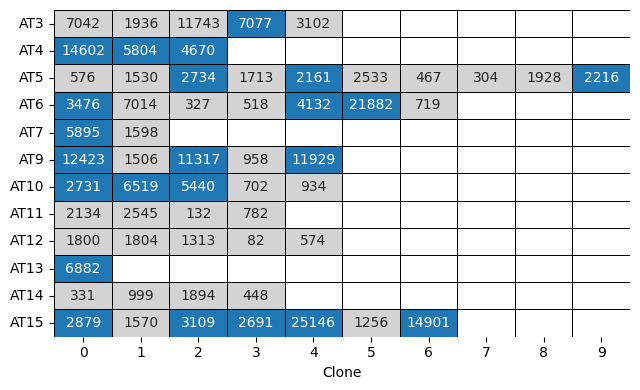

In [ ]:
plt.figure(figsize=(6.5,4))
ax = plt.gca()

sns.heatmap(
    count_df,
    mask=pass_df,          # hide grey cells
    cmap=["#d3d3d3"],
    annot=True,
    fmt=".0f",
    cbar=False,
    linewidths=0.5,
    linecolor="black",
    ax=ax
)

sns.heatmap(
    count_df,
    mask=(pass_df==False),
    cmap=["#1f77b4"],
    annot=True,
    fmt=".0f",
    cbar=False,
    linewidths=0.5,
    linecolor="black",
    ax=ax
)

plt.xlabel("Clone")
plt.ylabel("")
plt.tight_layout()
plt.savefig(outdir+'good_clones.pdf')

In [ ]:
count_df.to_csv('../../../data/EDFig6/EDFig6c.csv')

In [ ]:
clones_order = ['at4_0',
 'at10_1',
 'at15_3',
 'at4_2',
 'at6_0',
 'at4_1',
 'at10_2',
 'at9_2',
 'at15_4',
 'at15_0',
 'at15_6',
 'at15_2',
 'at10_0',
 'at5_2',
 'at9_4',
 'at9_0',
 'at5_9',
 'at5_4',
 'at3_3',
 'at13_0',
 'at6_4',
 'at7_0',
 'at6_5']

In [ ]:
df = all_scores[(all_scores['pass']==True) & 
    (all_scores['pass_counts']==True)].set_index('index')[['donor']]

df = df.reindex(clones_order)

# map categories → colors
ids = df["donor"]
colors = dict(zip(ids.unique(), plt.cm.Set3.colors[:ids.nunique()]))

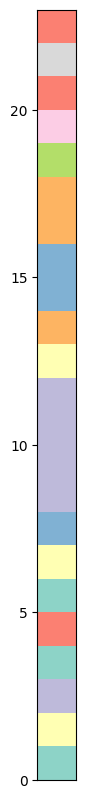

In [ ]:
fig, ax = plt.subplots(figsize=(0.5,10))

bottom = 0
for cat in ids:
    ax.bar(
        x=0,
        height=1,
        bottom=bottom,
        color=colors[cat],
        width=1
    )
    bottom += 1

ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylim(0, len(ids))
plt.savefig(outdir+'donor_col.pdf')